<hr>

# Chapter 04 — MDPs and Planning Under Uncertainty
<hr>

**Theme**: when the rules of the environment are known, an agent can plan before acting.

This course is notebook-first, where each chapter is represented as a notebook. Each notebook is designed to be read top-to-bottom and run as you go.

### What you will learn
- How a Markov decision process describes states, actions, transitions, rewards, and discounting.
- How stochastic transitions change which route is best.
- How the Bellman optimality backup compares actions using expected future return.
- How value iteration turns a known model into an optimal policy.
- How planning differs from learning through sampled experience.

### Prereqs
- Chapters 01–03
- Python basics and NumPy arrays
- Comfort with probability-weighted averages

### Estimated time
- 60–75 minutes

<br>
<br>
<hr>
<br>
<br>


# 1. Introduction

Imagine a delivery robot carrying an urgent parcel through a warehouse.

The shortest route runs beside hazardous loading bays. Under perfect movement, the shortcut is clearly best. But the robot's wheels sometimes slip sideways. A small steering error near a loading bay can end the delivery.

A longer route follows the outer walls. It costs more time, but walls protect the robot from many sideways slips.

The robot must therefore answer a planning question:

> Is the time saved by the shortcut worth the risk?

In Chapter 03, Q-learning answered questions by collecting experience and updating a Q-table. This chapter starts from a different assumption: the transition probabilities and rewards are already known.

That lets the agent **plan**. It can consider possible outcomes mathematically before executing a route.

<br>
<br>
<hr>
<br>
<br>


# 2. From the RL Loop to an MDP

A finite Markov decision process is commonly written as:

$$
(\mathcal{S}, \mathcal{A}, P, R, \gamma).
$$

| Component | Meaning | Delivery example |
|---|---|---|
| $\mathcal{S}$ | possible states | open grid squares |
| $\mathcal{A}$ | possible actions | north, south, west, east |
| $P$ | transition model | probabilities of intended movement and slips |
| $R$ | reward model | goal reward, hazard penalty, step cost |
| $\gamma$ | discount factor | how strongly future rewards count |

The **Markov property** says that the current state contains the information needed to describe the next-state distribution, given an action:

$$
\Pr(S_{t+1}\mid S_t,A_t,\text{past})
=
\Pr(S_{t+1}\mid S_t,A_t).
$$

For this task, the robot's grid position is enough. The walls, hazards, goal, rewards, and slip probability do not change during an episode.

### Model, policy, and value

- A **model** describes what can happen after each action.
- A **policy** tells the robot which action to choose.
- A **value function** describes expected future return.
- An **optimal policy** achieves the largest expected return from every state.

<br>
<br>
<hr>
<br>
<br>


# 3. Worked Transition by Hand

Suppose the robot chooses `east` and:

- moves east with probability `0.8`
- slips north with probability `0.1`
- slips south with probability `0.1`

If a wall blocks an outcome, the robot stays in place.

Imagine the three possible outcomes currently have:

| Outcome | Probability | Reward | Next-state value |
|---|---:|---:|---:|
| east | `0.8` | `-0.1` | `4.0` |
| north | `0.1` | `-20.0` | `0.0` |
| south is blocked | `0.1` | `-0.1` | `3.0` |

With $\gamma=0.95$, the look-ahead value of choosing east is:

$$
\begin{aligned}
q(s,\text{east})
&= 0.8[-0.1 + 0.95(4.0)]\\
&\quad + 0.1[-20.0]\\
&\quad + 0.1[-0.1 + 0.95(3.0)]\\
&= 1.23.
\end{aligned}
$$

This is an **expectation**: a probability-weighted average of possible outcomes. Planning under uncertainty does not ask only what usually happens. Low-probability, high-cost outcomes can change the best action.

<br>
<br>
<hr>
<br>
<br>


# 4. The Stochastic Delivery Grid

The grid contains two routes from `S` to `G`:

- a four-step shortcut along the bottom
- a twelve-step outer route along the left, top, and right walls

`H` marks hazardous terminal squares beside the shortcut. Grey squares are walls.

Rewards:

- goal: `+10`
- hazard: `-20`
- ordinary transition: `-0.1`

> **Reading guidance:** the next code cell defines the MDP and its transition model. It is supporting infrastructure. Understand the inputs and outputs, but do not feel obliged to read every line. The Bellman backup later is the code to study closely.


In [1]:
# If you're running this in a fresh environment, you only need numpy + matplotlib.
# Uncomment below as required:

# %pip install numpy
# %pip install matplotlib

from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True

ACTIONS = ("north", "south", "west", "east")
MOVE = {
    "north": (-1, 0),
    "south": (1, 0),
    "west": (0, -1),
    "east": (0, 1),
}
PERPENDICULAR = {
    "north": ("west", "east"),
    "south": ("east", "west"),
    "west": ("south", "north"),
    "east": ("north", "south"),
}
ARROWS = {"north": "↑", "south": "↓", "west": "←", "east": "→"}


class DeliveryGridMDP:
    '''Known-model stochastic delivery grid.'''

    def __init__(
        self,
        slip_probability=0.15,
        step_cost=-0.1,
        goal_reward=10.0,
        hazard_reward=-20.0,
    ):
        self.grid_size = 5
        self.start = (4, 0)
        self.goal = (4, 4)
        self.hazards = frozenset({(3, 1), (3, 2), (3, 3)})
        self.terminal_states = self.hazards | {self.goal}
        self.actions = ACTIONS
        self.slip_probability = float(slip_probability)
        self.step_cost = float(step_cost)
        self.goal_reward = float(goal_reward)
        self.hazard_reward = float(hazard_reward)

        outer_route = (
            {(row, 0) for row in range(5)}
            | {(0, col) for col in range(5)}
            | {(row, 4) for row in range(5)}
        )
        shortcut = {(4, col) for col in range(5)}
        self.open_states = outer_route | shortcut | set(self.hazards)
        self.states = tuple(sorted(self.open_states))
        self.walls = {
            (row, col)
            for row in range(self.grid_size)
            for col in range(self.grid_size)
            if (row, col) not in self.open_states
        }

    def _move(self, state, action):
        d_row, d_col = MOVE[action]
        candidate = (state[0] + d_row, state[1] + d_col)
        return candidate if candidate in self.open_states else state

    def transitions(self, state, action):
        '''Return (probability, next_state, reward, terminal) outcomes.'''
        if state in self.terminal_states:
            return [(1.0, state, 0.0, True)]

        slip = self.slip_probability
        action_probabilities = [
            (1.0 - slip, action),
            (slip / 2.0, PERPENDICULAR[action][0]),
            (slip / 2.0, PERPENDICULAR[action][1]),
        ]

        next_state_probabilities = defaultdict(float)
        for probability, realised_action in action_probabilities:
            next_state = self._move(state, realised_action)
            next_state_probabilities[next_state] += probability

        outcomes = []
        for next_state, probability in next_state_probabilities.items():
            terminal = next_state in self.terminal_states
            if next_state == self.goal:
                reward = self.goal_reward
            elif next_state in self.hazards:
                reward = self.hazard_reward
            else:
                reward = self.step_cost
            outcomes.append((probability, next_state, reward, terminal))

        return outcomes


mdp = DeliveryGridMDP(slip_probability=0.15)

for state in mdp.states:
    for action in mdp.actions:
        total_probability = sum(
            outcome[0] for outcome in mdp.transitions(state, action)
        )
        assert np.isclose(total_probability, 1.0)

print(f"MDP ready: {len(mdp.states)} states and {len(mdp.actions)} actions.")


MDP ready: 19 states and 4 actions.


## 4.1 Visualise the Grid

The route geometry is part of the decision problem. The shortcut is visibly shorter, but its middle squares sit directly below hazards.


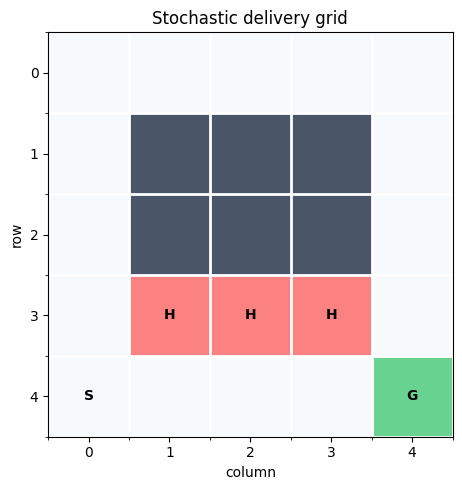

In [2]:
def draw_delivery_grid(ax, mdp, title="Stochastic delivery grid"):
    grid = np.zeros((mdp.grid_size, mdp.grid_size))
    for wall in mdp.walls:
        grid[wall] = 1
    for hazard in mdp.hazards:
        grid[hazard] = 2
    grid[mdp.goal] = 3

    colours = ListedColormap(["#f7fafc", "#4a5568", "#fc8181", "#68d391"])
    ax.imshow(grid, cmap=colours, vmin=0, vmax=3)

    for row, col in mdp.hazards:
        ax.text(col, row, "H", ha="center", va="center", weight="bold")
    ax.text(mdp.start[1], mdp.start[0], "S", ha="center", va="center", weight="bold")
    ax.text(mdp.goal[1], mdp.goal[0], "G", ha="center", va="center", weight="bold")

    ax.set_title(title)
    ax.set_xticks(range(mdp.grid_size))
    ax.set_yticks(range(mdp.grid_size))
    ax.set_xticks(np.arange(-0.5, mdp.grid_size, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, mdp.grid_size, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=2)
    ax.grid(which="major", visible=False)
    ax.set_xlabel("column")
    ax.set_ylabel("row")


fig, ax = plt.subplots(figsize=(6, 5))
draw_delivery_grid(ax, mdp)
plt.tight_layout()
plt.show()


## 4.2 Inspect One Transition Distribution

The robot is at `(4, 2)`, directly below a hazard, and chooses `east`.

The bar chart shows the complete model output for that decision. One action can lead to several next states.


P=0.85 -> state=(4, 3), reward= -0.1, terminal=False
P=0.07 -> state=(3, 2), reward=-20.0, terminal=True
P=0.07 -> state=(4, 2), reward= -0.1, terminal=False


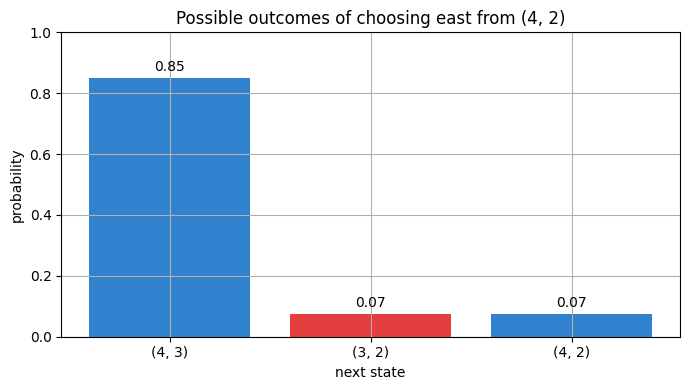

In [3]:
example_state = (4, 2)
example_action = "east"
example_outcomes = mdp.transitions(example_state, example_action)

for probability, next_state, reward, terminal in example_outcomes:
    print(
        f"P={probability:.2f} -> state={next_state}, "
        f"reward={reward:5.1f}, terminal={terminal}"
    )

labels = [str(outcome[1]) for outcome in example_outcomes]
probabilities = [outcome[0] for outcome in example_outcomes]
bar_colours = [
    "#e53e3e" if outcome[1] in mdp.hazards else "#3182ce"
    for outcome in example_outcomes
]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, probabilities, color=bar_colours)
ax.bar_label(bars, fmt="%.2f", padding=3)
ax.set_ylim(0, 1)
ax.set_title("Possible outcomes of choosing east from (4, 2)")
ax.set_xlabel("next state")
ax.set_ylabel("probability")
plt.tight_layout()
plt.show()


# 5. Bellman Optimality

For each action, we can calculate a one-step look-ahead value:

$$
q(s,a)
=
\sum_{s',r}p(s',r\mid s,a)
\left[r+\gamma V(s')\right].
$$

Bellman optimality chooses the action with the largest look-ahead value:

$$
V^*(s)
=
\max_a
\sum_{s',r}p(s',r\mid s,a)
\left[r+\gamma V^*(s')\right].
$$

In plain language:

1. consider an action
2. list every possible outcome
3. combine immediate reward with discounted next-state value
4. weight each outcome by its probability
5. repeat for every action
6. keep the largest result

This resembles the Q-values from Chapter 03. The difference is where the information comes from:

- Q-learning estimates action values from sampled experience.
- A Bellman backup calculates action values from the known model.

<br>
<br>
<hr>
<br>
<br>


# 6. Core Coding Exercise: Implement the Bellman Backup

The function below is the most important code in this chapter.

It receives:

- one state
- the current value estimate for every state
- the known MDP
- the discount factor

It returns the best backed-up value and the action that produced it.

### Exercise

Read this function carefully, then recreate its central loop yourself. A solution is included at the bottom of the notebook.


In [4]:
def bellman_optimality_backup(state, values, mdp, gamma=0.95):
    '''Return the best one-step look-ahead value and action.'''
    if state in mdp.terminal_states:
        return 0.0, None

    action_values = []

    for action in mdp.actions:
        expected_return = 0.0

        for probability, next_state, reward, terminal in mdp.transitions(
            state,
            action,
        ):
            next_value = 0.0 if terminal else values[next_state]
            expected_return += probability * (
                reward + gamma * next_value
            )

        action_values.append(expected_return)

    best_index = int(np.argmax(action_values))
    return action_values[best_index], mdp.actions[best_index]


# Recreate the hand-worked example from Section 3.
worked_mdp = DeliveryGridMDP(slip_probability=0.20)
worked_values = {state: -100.0 for state in worked_mdp.states}
worked_values[(4, 2)] = 3.0
worked_values[(4, 3)] = 4.0
backed_up_value, backed_up_action = bellman_optimality_backup(
    (4, 2),
    worked_values,
    worked_mdp,
    gamma=0.95,
)

assert backed_up_action == "east"
assert np.isclose(backed_up_value, 1.235)
print(
    f"Backup at (4, 2): value={backed_up_value:.3f}, "
    f"best action={backed_up_action}"
)


Backup at (4, 2): value=1.235, best action=east


# 7. Value Iteration

One Bellman backup improves one state's value. **Value iteration** repeatedly applies that operation to every non-terminal state.

The algorithm stops when a full sweep changes no value by more than a small tolerance.

> **This loop is also worth reading.** Most of the mathematical work remains inside `bellman_optimality_backup`; value iteration simply applies it repeatedly and records convergence.


In [5]:
def value_iteration(
    mdp,
    gamma=0.95,
    tolerance=1e-8,
    max_sweeps=1000,
):
    '''Compute optimal values and a greedy policy from a known MDP.'''
    values = {state: 0.0 for state in mdp.states}
    value_history = [values.copy()]
    max_changes = []

    for _ in range(max_sweeps):
        new_values = values.copy()

        for state in mdp.states:
            if state not in mdp.terminal_states:
                new_values[state], _ = bellman_optimality_backup(
                    state,
                    values,
                    mdp,
                    gamma,
                )

        max_change = max(
            abs(new_values[state] - values[state])
            for state in mdp.states
        )
        values = new_values
        value_history.append(values.copy())
        max_changes.append(max_change)

        if max_change < tolerance:
            break

    policy = {}
    for state in mdp.states:
        if state not in mdp.terminal_states:
            _, policy[state] = bellman_optimality_backup(
                state,
                values,
                mdp,
                gamma,
            )

    return values, policy, value_history, np.array(max_changes)


values, policy, value_history, max_changes = value_iteration(mdp)

print(f"Converged after {len(max_changes)} sweeps.")
print(f"Optimal start action: {policy[mdp.start]}")
print(f"Optimal start value: {values[mdp.start]:.3f}")


Converged after 94 sweeps.
Optimal start action: east
Optimal start value: 2.175


## 7.1 Watch Value Spread Through the Grid

All non-terminal values begin at zero. The goal reward first affects nearby states, then propagates backwards through repeated sweeps.

The hazard penalty also propagates backwards. States are valuable not only because they lead towards reward, but also because their actions can avoid costly outcomes.

> **Reading guidance:** the plotting functions are visualisation scaffolding. Run them and interpret the figures; the Bellman backup and value-iteration loop contain the core algorithm.


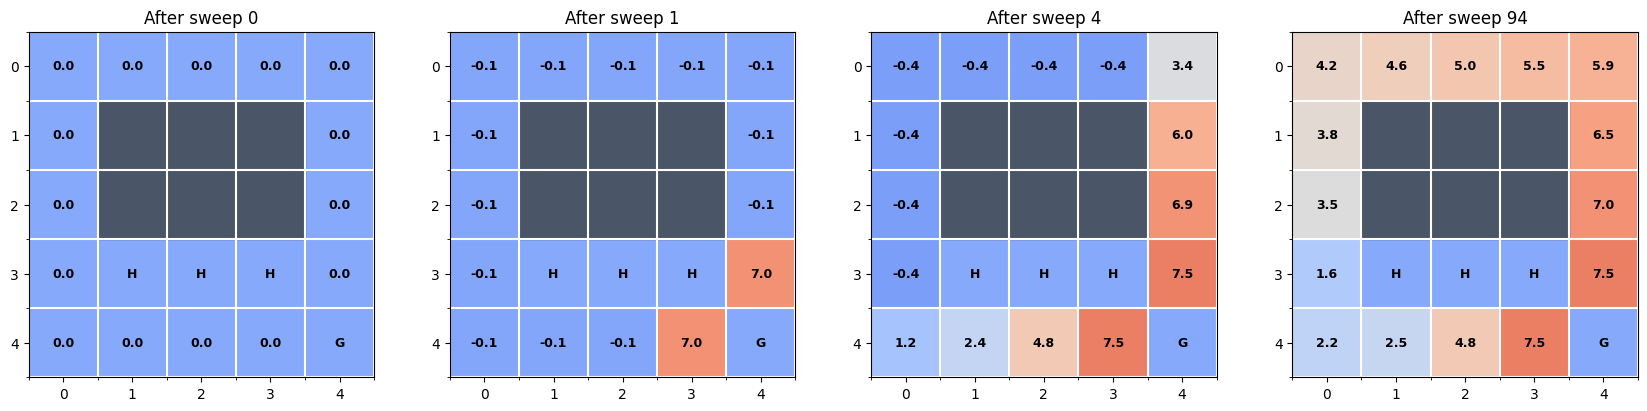

In [6]:
def values_to_grid(values, mdp):
    grid = np.full((mdp.grid_size, mdp.grid_size), np.nan)
    for state in mdp.states:
        grid[state] = values.get(state, 0.0)
    return grid


def draw_values(ax, values, mdp, title, policy=None, vmin=-3, vmax=10):
    grid = values_to_grid(values, mdp)
    image = ax.imshow(grid, cmap="coolwarm", vmin=vmin, vmax=vmax)

    for wall in mdp.walls:
        ax.add_patch(
            plt.Rectangle(
                (wall[1] - 0.5, wall[0] - 0.5),
                1,
                1,
                color="#4a5568",
            )
        )

    for state in mdp.states:
        row, col = state
        if state in mdp.hazards:
            label = "H"
        elif state == mdp.goal:
            label = "G"
        elif policy is not None and state in policy:
            label = ARROWS[policy[state]]
        else:
            label = f"{values[state]:.1f}"
        ax.text(col, row, label, ha="center", va="center", fontsize=9, weight="bold")

    ax.set_title(title)
    ax.set_xticks(range(mdp.grid_size))
    ax.set_yticks(range(mdp.grid_size))
    ax.set_xticks(np.arange(-0.5, mdp.grid_size, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, mdp.grid_size, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.5)
    ax.grid(which="major", visible=False)
    return image


selected_sweeps = [0, 1, 4, len(value_history) - 1]
fig, axs = plt.subplots(1, 4, figsize=(17, 4))

for ax, sweep in zip(axs, selected_sweeps):
    draw_values(
        ax,
        value_history[sweep],
        mdp,
        f"After sweep {sweep}",
    )

plt.tight_layout()
plt.show()


## 7.2 Convergence and the Final Policy

The convergence plot tracks the largest value change in each sweep. Once this quantity becomes tiny, further sweeps no longer meaningfully alter the solution.

The arrow plot shows the greedy action selected from the converged values.


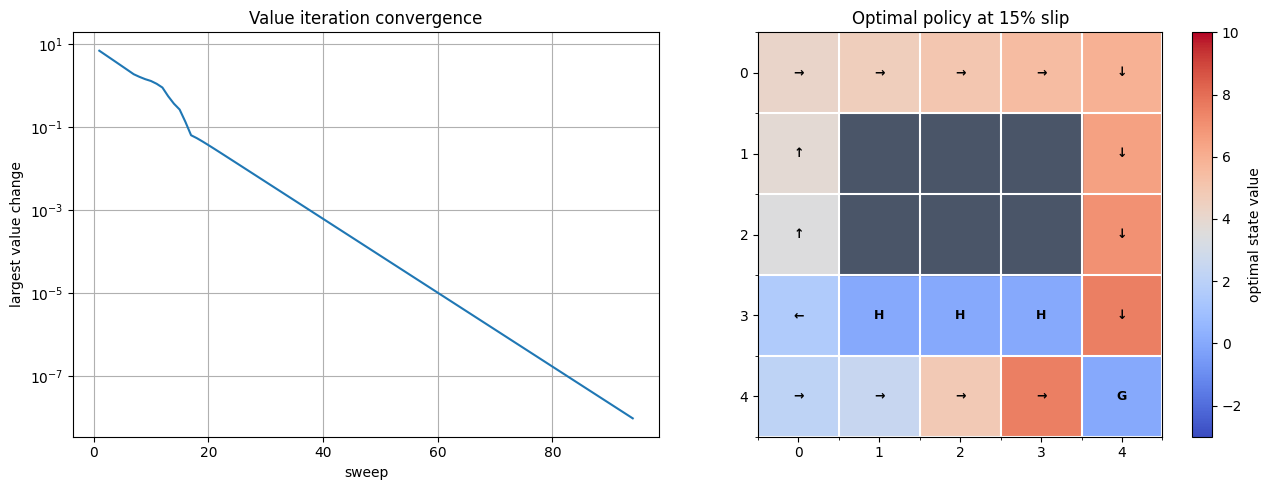

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(13, 5))

axs[0].semilogy(np.arange(1, len(max_changes) + 1), max_changes)
axs[0].set_title("Value iteration convergence")
axs[0].set_xlabel("sweep")
axs[0].set_ylabel("largest value change")

image = draw_values(
    axs[1],
    values,
    mdp,
    "Optimal policy at 15% slip",
    policy=policy,
)
fig.colorbar(image, ax=axs[1], label="optimal state value")

plt.tight_layout()
plt.show()


# 8. Risk Changes the Optimal Policy

We now solve the same MDP three times:

- **deterministic**: no slip
- **moderate uncertainty**: `15%` total slip probability
- **high uncertainty**: `30%` total slip probability

Nothing learns from trial and error here. Each policy is recomputed from a different known transition model.

The key state is `S`:

- an east arrow enters the shortcut
- a north arrow begins the long safe route


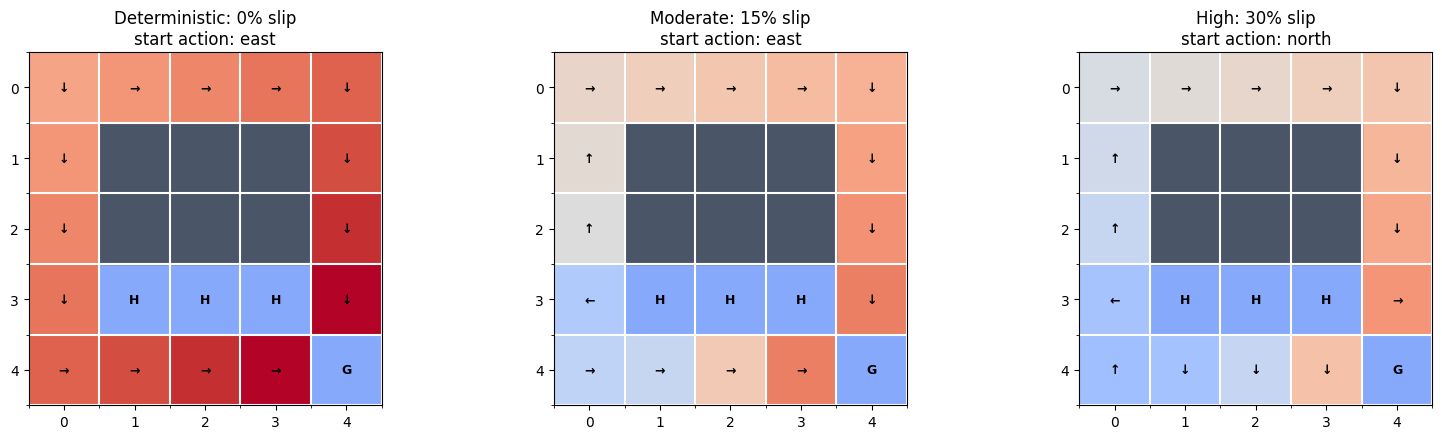

In [8]:
scenario_slips = {
    "Deterministic: 0% slip": 0.0,
    "Moderate: 15% slip": 0.15,
    "High: 30% slip": 0.30,
}
scenario_results = {}

fig, axs = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (name, slip_probability) in zip(axs, scenario_slips.items()):
    scenario_mdp = DeliveryGridMDP(slip_probability=slip_probability)
    scenario_values, scenario_policy, history, changes = value_iteration(
        scenario_mdp
    )
    scenario_results[name] = {
        "mdp": scenario_mdp,
        "values": scenario_values,
        "policy": scenario_policy,
        "changes": changes,
    }
    draw_values(
        ax,
        scenario_values,
        scenario_mdp,
        f"{name}\nstart action: {scenario_policy[scenario_mdp.start]}",
        policy=scenario_policy,
    )

plt.tight_layout()
plt.show()

assert scenario_results["Deterministic: 0% slip"]["policy"][(4, 0)] == "east"
assert scenario_results["High: 30% slip"]["policy"][(4, 0)] == "north"


### What you should notice

- With deterministic movement, the shortcut is optimal.
- At moderate uncertainty, the shortcut still has enough expected value to justify its risk.
- At high uncertainty, the optimal start action changes to north.
- The safest policy can be slower while still having higher expected value than repeatedly risking a severe penalty.

An optimal policy is always optimal **for a particular MDP specification**. Change the transition model or rewards, and the optimal policy may change.

<br>
<br>
<hr>
<br>
<br>


# 9. Test the Planned Policies with Simulation

Value iteration calculated each policy from the model. Simulation gives us a second way to understand those policies by sampling actual trajectories.

We will measure:

- delivery success rate
- hazard rate
- episode length
- discounted return

> **Reading guidance:** this is evaluation machinery, similar to Chapter 03. Focus on the plots and their interpretation rather than every helper line.


In [9]:
def sample_transition(mdp, state, action, rng):
    outcomes = mdp.transitions(state, action)
    probabilities = [outcome[0] for outcome in outcomes]
    index = int(rng.choice(len(outcomes), p=probabilities))
    return outcomes[index]


def simulate_policy(
    mdp,
    policy,
    n_episodes=1000,
    gamma=0.95,
    max_steps=100,
    seed=7,
):
    rng = np.random.default_rng(seed)
    records = []

    for _ in range(n_episodes):
        state = mdp.start
        total_return = 0.0
        discount = 1.0

        for step in range(1, max_steps + 1):
            probability, next_state, reward, terminal = sample_transition(
                mdp,
                state,
                policy[state],
                rng,
            )
            total_return += discount * reward
            discount *= gamma
            state = next_state

            if terminal:
                break

        records.append(
            {
                "success": state == mdp.goal,
                "hazard": state in mdp.hazards,
                "length": step,
                "return": total_return,
            }
        )

    return records


for name, result in scenario_results.items():
    records = simulate_policy(result["mdp"], result["policy"])
    result["records"] = records
    result["metrics"] = {
        "success": np.mean([record["success"] for record in records]),
        "hazard": np.mean([record["hazard"] for record in records]),
        "length": np.mean([record["length"] for record in records]),
        "return": np.mean([record["return"] for record in records]),
    }

    metrics = result["metrics"]
    print(
        f"{name:24s} | success={metrics['success']:.1%} "
        f"| hazard={metrics['hazard']:.1%} "
        f"| steps={metrics['length']:.1f} "
        f"| return={metrics['return']:.2f}"
    )


Deterministic: 0% slip   | success=100.0% | hazard=0.0% | steps=4.0 | return=8.29
Moderate: 15% slip       | success=76.7% | hazard=23.3% | steps=5.2 | return=1.80


High: 30% slip           | success=99.9% | hazard=0.0% | steps=31.2 | return=1.09


## 9.1 Visualise the Sampled Outcomes

The bar charts summarise average behaviour across the simulated episodes. The histogram then shows information hidden by an average: under moderate uncertainty, the shortcut produces both successful deliveries and severe hazard outcomes.

The plotting code is presentation scaffolding. Focus on the comparison between scenarios.


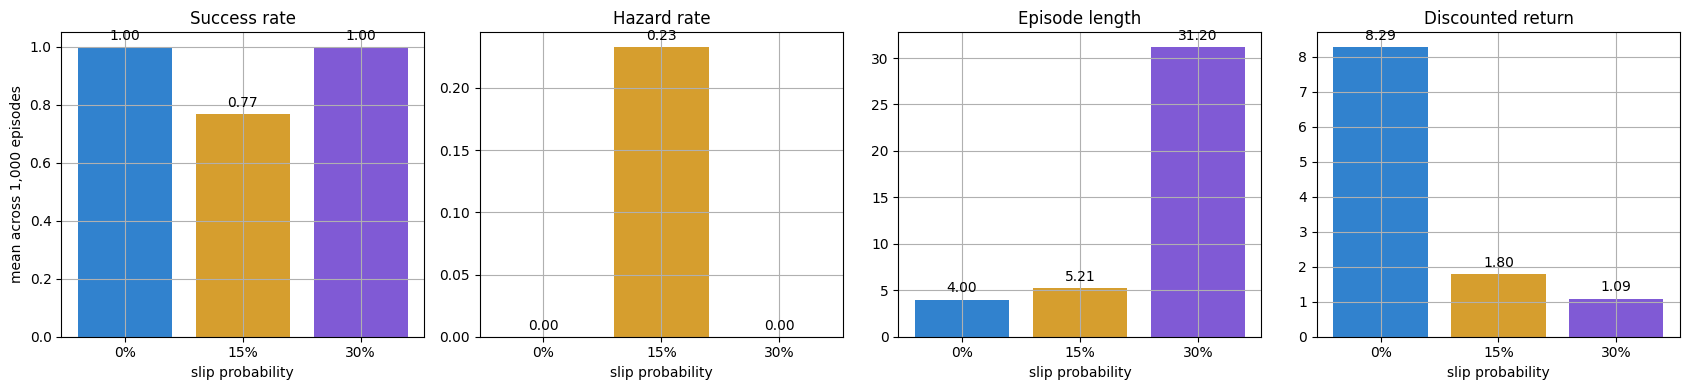

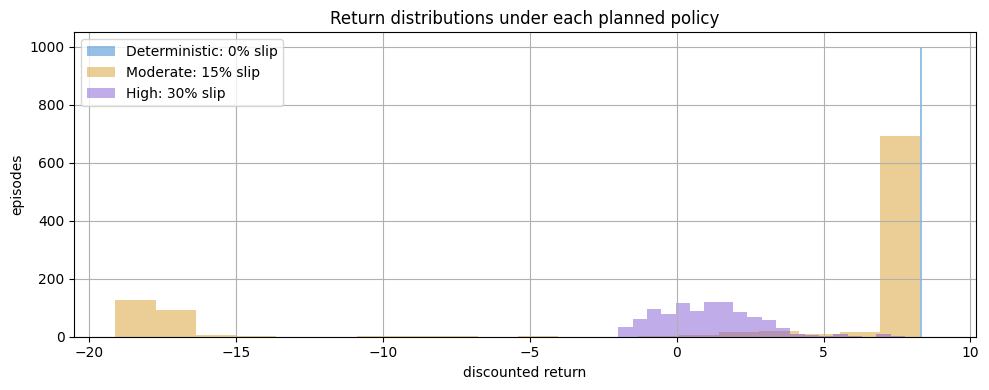

In [10]:
metric_specs = [
    ("Success rate", "success"),
    ("Hazard rate", "hazard"),
    ("Episode length", "length"),
    ("Discounted return", "return"),
]
scenario_names = list(scenario_results)
colours = ["#3182ce", "#d69e2e", "#805ad5"]

fig, axs = plt.subplots(1, 4, figsize=(17, 4))
for ax, (title, metric_key) in zip(axs, metric_specs):
    metric_values = [
        scenario_results[name]["metrics"][metric_key]
        for name in scenario_names
    ]
    bars = ax.bar(["0%", "15%", "30%"], metric_values, color=colours)
    ax.bar_label(bars, fmt="%.2f", padding=3)
    ax.set_title(title)
    ax.set_xlabel("slip probability")

axs[0].set_ylabel("mean across 1,000 episodes")
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(10, 4))
for name, colour in zip(scenario_names, colours):
    returns = [
        record["return"]
        for record in scenario_results[name]["records"]
    ]
    ax.hist(returns, bins=20, alpha=0.5, label=name, color=colour)

ax.set_title("Return distributions under each planned policy")
ax.set_xlabel("discounted return")
ax.set_ylabel("episodes")
ax.legend()
plt.tight_layout()
plt.show()


### Interpreting the simulation

- The deterministic case always follows the short route successfully.
- Moderate uncertainty makes the shortcut produce two clusters: successful deliveries and costly hazard failures.
- High uncertainty selects the protected route, greatly reducing hazard failures.
- The safe route takes more steps and discounts the goal more heavily.
- Expected return balances all of these outcomes; success rate alone does not define optimality.

Planning and simulation play different roles:

- planning uses the complete model to compute a policy
- simulation samples trajectories to help us inspect that policy

<br>
<br>
<hr>
<br>
<br>


# 10. Diving Deeper

This section adds mathematical detail. You can skip it without losing the main story.

### 10.1 From action values to state values

For any candidate value function:

$$
q(s,a)
=
\sum_{s',r}p(s',r\mid s,a)
\left[r+\gamma V(s')\right].
$$

The optimal state value is the best available action value:

$$
V^*(s)=\max_a q^*(s,a).
$$

An optimal policy can then be extracted greedily:

$$
\pi^*(s)\in\arg\max_a q^*(s,a).
$$

### 10.2 Synchronous versus in-place updates

Our implementation is **synchronous**:

- every state in a sweep reads from the old value table
- the new table replaces it after the sweep

An in-place implementation updates values immediately and may converge faster, but its behaviour depends on update order. Synchronous updates make the visual propagation easier to explain.

### 10.3 Why value iteration converges

For a finite discounted MDP with $\gamma<1$, the Bellman optimality operator is a contraction. Informally, applying it pulls different value estimates closer together by at least a factor related to $\gamma$.

Repeated backups therefore approach one unique fixed point: $V^*$.

### 10.4 Limits of exact planning

Value iteration is practical here because:

- the state space is small
- every action's transition distribution is known
- values can be stored in a table

Large or unknown environments break these assumptions. Later methods estimate values from sampled experience, use function approximation, learn models, or combine planning and learning.

### If you want to go deeper

- Sutton & Barto (2018), Chapters 3 and 4
- Richard Bellman, *Dynamic Programming*
- David Silver's lectures on MDPs and dynamic programming

<br>
<br>
<hr>
<br>
<br>


# 11. Knowledge Check

### Tier 1: concept checks (5–10 minutes)

1. What information does a transition model provide?
2. Why is the value of an action a probability-weighted average?
3. What does the `max` operation do in the Bellman optimality equation?
4. How does value iteration differ from Chapter 03's Q-learning?
5. Why can the longer route be optimal?
6. What does convergence mean in the value-iteration plot?

### Tier 2: small coding change (15–30 minutes)

Choose one:

- Change slip probability gradually between `0.15` and `0.30`. At approximately what value does the start action switch?
- Make the hazard penalty `-10` instead of `-20`. Does the shortcut remain optimal for longer?
- Try `gamma = 0.7` and `gamma = 0.99`. How does discounting affect the longer route?

State your prediction before running the experiment.

### Tier 3: extension (30–60 minutes)

Add one wall or move one hazard. Then:

1. sketch your expected optimal route
2. rerun value iteration
3. compare the new policy and simulation metrics
4. explain any difference between your prediction and the result

<br>
<br>
<hr>
<br>
<br>


# 12. Takeaways

- An MDP specifies states, actions, transitions, rewards, and discounting.
- A known model lets an agent plan without first collecting training episodes.
- Bellman optimality compares actions through expected immediate reward and future value.
- Value iteration repeatedly applies Bellman backups until values converge.
- Transition uncertainty and severe outcomes can make a longer route optimal.
- Optimality is relative to the specified model, rewards, and discount factor.
- Visualising value propagation, policy arrows, and return distributions reveals different parts of the planning process.

### Common pitfalls

- treating the most likely outcome as the only outcome
- confusing a planned policy with a policy learned from experience
- assuming the shortest route must have the highest expected return
- forgetting that terminal next states have no future value
- comparing policies from different MDPs without noting what changed

<br>
<br>
<hr>
<br>
<br>

# 13. What's Next

- Next notebook: **Monte Carlo methods**, where the agent will estimate values from complete sampled episodes without requiring a transition model.
- Suggested reading: Sutton & Barto (2018), Chapters 3–5.

<br>
<br>
<hr>
<br>
<br>


In [11]:
######################################################################
######################## ANSWERS BELOW ###############################
######################################################################
######################## ANSWERS BELOW ###############################
######################################################################
######################## ANSWERS BELOW ###############################
######################################################################


## Answer to the Bellman Backup Exercise

```python
def bellman_optimality_backup(state, values, mdp, gamma=0.95):
    if state in mdp.terminal_states:
        return 0.0, None

    action_values = []

    for action in mdp.actions:
        expected_return = 0.0

        for probability, next_state, reward, terminal in mdp.transitions(
            state,
            action,
        ):
            next_value = 0.0 if terminal else values[next_state]
            expected_return += probability * (
                reward + gamma * next_value
            )

        action_values.append(expected_return)

    best_index = int(np.argmax(action_values))
    return action_values[best_index], mdp.actions[best_index]
```

<hr style="border: none; border-top: 2px dashed #999; margin: 24px 0;">

## Answers to Concept Checks

### 1. What information does a transition model provide?

It gives the possible next states and rewards after a state-action pair, together with their probabilities.

### 2. Why is action value a probability-weighted average?

The same action can produce different outcomes. Expected value combines all of them while giving more likely outcomes more influence.

### 3. What does the `max` operation do?

It selects the action with the largest expected look-ahead return. This turns policy evaluation into an optimality calculation.

### 4. How does value iteration differ from Q-learning?

Value iteration computes with a known model and sweeps across states. Q-learning samples transitions from experience and updates only the state-action pair that was visited.

### 5. Why can the longer route be optimal?

Its additional step costs can be smaller than the expected cost of occasionally entering a severe hazard on the shortcut.

### 6. What does convergence mean?

Successive Bellman sweeps no longer change the value estimates by a meaningful amount. The values are close to the Bellman optimality fixed point.
